<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab #7: Debugging Deep Learning Pipelines</h2>
Semester 1, 2026<br>
</center>

**Due**: 11:59pm on Sunday 26 Apr, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging. Note that this code will not be run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`).

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

In [1]:
student_name = "Weiyi Jiang"
student_id = "u8191809"

In [2]:
import sys
import getpass
import math
from pathlib import Path

def is_notebook():
    return "ipykernel" in sys.modules

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
import matplotlib.pyplot as plt

print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
print("Python Version: {}".format(sys.version))
print("PyTorch Version: {}".format(torch.__version__))

User: cichlidfish (Weiyi Jiang, u8191809)
Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
PyTorch Version: 2.10.0


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random_seed = 3242
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)
    
print("Using Device: {}".format(device))

Using Device: cpu


## Loading and Exploring the Data

In this lab you will debug a deliberately broken deep learning pipeline. The goal is **not** to invent a better model. The goal is to learn a debugging workflow:

**inspect → test → isolate → fix → verify**

We will use a synthetic **10-class classification** dataset. Each example has a **2-D float feature vector** (`x1`, `x2`) and a **string class label** drawn from the alphabet `{"a", "b", "c", "d", "e", "f", "g", "h", "i", "j"}`. The data is stored in `data/lab07_strings.csv`. A custom `Dataset` class reads the CSV and converts each string label to an integer class index inside `__getitem__`.

In [4]:
DATA_PATH = Path("./data/lab07_strings.csv")


class StringLabelDataset(Dataset):
    """Loads 2-D float features and string class labels from a CSV file.

    CSV format: columns x1 (float), x2 (float), class_label (str).
    The class_label is one of: "a", "b", "c", "d", "e", "f", "g", "h", "i", "j".
    __getitem__ converts each string label to an integer class index.
    """

    def __init__(self, df):
        """
        Args:
            df: pandas DataFrame with columns x1, x2, class_label
        """
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x   = torch.tensor([float(row['x1']), float(row['x2'])], dtype=torch.float32)
        s   = row['class_label']

        if s == 'a':
            y = 0
        elif s == 'b':
            y = 1
        elif s == 'c':
            y = 2
        elif s == 'd':
            y = 3
        elif s == 'e':
            y = 4
        elif s == 'f':
            y = 5
        elif s == 'g':
            y = 6
        elif s == 'h':
            y = 7
        elif s == 'i':
            y = 8
        elif s == 'j':
            y = 8

        return x, torch.tensor(y, dtype=torch.long)


if is_notebook():
    df_full  = pd.read_csv(DATA_PATH)
    split    = int(0.8 * len(df_full))
    train_df = df_full.iloc[:split].reset_index(drop=True)
    val_df   = df_full.iloc[split:].reset_index(drop=True)

    train_dataset = StringLabelDataset(train_df)
    val_dataset   = StringLabelDataset(val_df)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False)

    # Extract tensors for the scatter visualisation (labels come through the dataset)
    X_train = torch.tensor(train_df[['x1', 'x2']].values, dtype=torch.float32)
    y_train = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))])

    print("Train size:", len(train_dataset))
    print("Val size:  ", len(val_dataset))
    print("CSV columns:", list(df_full.columns))
    print("Unique string labels:", sorted(df_full['class_label'].unique().tolist()))
    print("Unique integer labels from dataset:", y_train.unique(sorted=True).tolist())

Train size: 800
Val size:   200
CSV columns: ['x1', 'x2', 'class_label']
Unique string labels: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
Unique integer labels from dataset: [0, 1, 2, 3, 4, 5, 6, 7, 8]


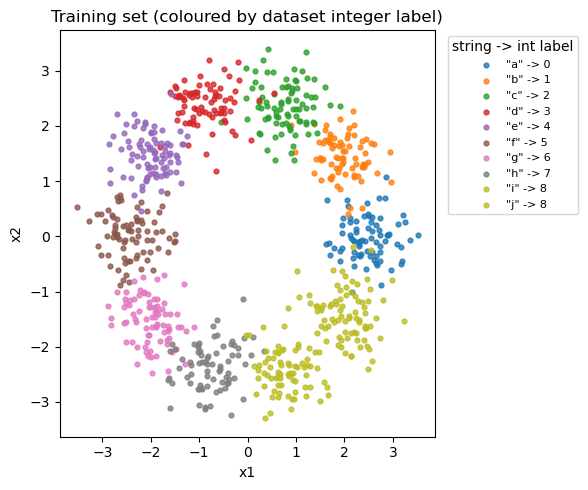

In [5]:
if is_notebook():
    import numpy as np
    string_labels = sorted(df_full['class_label'].unique().tolist())  # ["a".."j"]
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    fig, ax = plt.subplots(figsize=(6, 5))
    for lbl in string_labels:
        mask    = train_df['class_label'] == lbl
        int_lbl = y_train[mask.values][0].item()
        ax.scatter(
            train_df.loc[mask, 'x1'], train_df.loc[mask, 'x2'],
            color=tuple(colors[int_lbl]), s=12, alpha=0.8,
            label=f'"{lbl}" -> {int_lbl}'
        )
    ax.set_title("Training set (coloured by dataset integer label)")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend(title="string -> int label", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


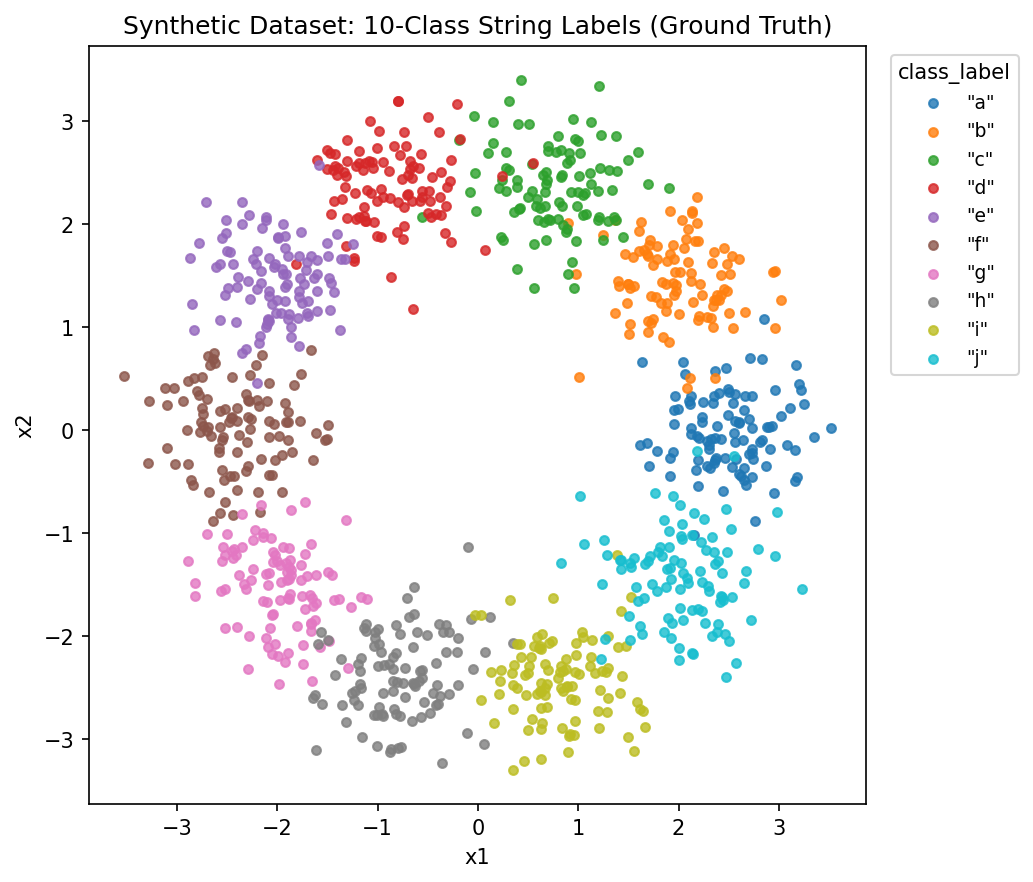

Figure: Ground-truth string class labels (10 distinct clusters, 10 colours).


In [6]:
if is_notebook():
    from IPython.display import Image, display
    display(Image("data/lab07_scatter.png"))
    print("Figure: Ground-truth string class labels (10 distinct clusters, 10 colours).")

---
## Task 1: Data and Label Debugging

A deep learning pipeline can look broken even when the model is fine. Before touching the model or optimizer, you should inspect the batch, check the labels, and verify the class distribution.

### 1.1 Inspecting a Batch

Implement `inspect_batch()`. This function should print the input shape, target shape, dtypes, devices, value ranges, and unique labels for a batch. The purpose is to make students look at the data first instead of randomly changing model code.

In [7]:
def inspect_batch(x, y, num_classes):
    """Print useful summary statistics for one batch.

    Args:
        x (torch.Tensor): input tensor of shape (batch, feature_dim)
        y (torch.Tensor): target tensor of shape (batch,), dtype torch.long
        num_classes (int): total number of classes

    Returns:
        summary (dict): must contain exactly these keys:
            "x_shape"       (tuple)       -- tuple(x.shape)
            "y_shape"       (tuple)       -- tuple(y.shape)
            "x_dtype"       (torch.dtype) -- x.dtype
            "y_dtype"       (torch.dtype) -- y.dtype
            "x_device"      (str)         -- str(x.device)
            "y_device"      (str)         -- str(y.device)
            "x_min"         (float)       -- x.min().item()
            "x_max"         (float)       -- x.max().item()
            "unique_labels" (list)        -- sorted list of unique int label values in y
    """
    summary = {
        "x_shape": tuple(x.shape),
        "y_shape": tuple(y.shape),
        "x_dtype": x.dtype,
        "y_dtype": y.dtype,
        "x_device": str(x.device),
        "y_device": str(y.device),
        "x_min": float(x.min().item()),
        "x_max": float(x.max().item()),
        "unique_labels": sorted(torch.unique(y).tolist()),
    }

    print("x shape:", summary["x_shape"])
    print("y shape:", summary["y_shape"])
    print("x dtype/device:", summary["x_dtype"], summary["x_device"])
    print("y dtype/device:", summary["y_dtype"], summary["y_device"])
    print("x range:", (summary["x_min"], summary["x_max"]))
    print("unique labels:", summary["unique_labels"])
    if summary["unique_labels"]:
        print("label range valid:", 0 <= min(summary["unique_labels"]) and max(summary["unique_labels"]) < num_classes)

    return summary


In [8]:
if is_notebook():
    xb, yb = next(iter(train_loader))
    summary = inspect_batch(xb, yb, num_classes=10)
    assert isinstance(summary, dict), "inspect_batch should return a dictionary"
    assert "x_shape" in summary and "y_shape" in summary, "Missing expected keys in summary"
    assert tuple(summary["x_shape"]) == tuple(xb.shape)
    assert tuple(summary["y_shape"]) == tuple(yb.shape)
    print("Task 1.1 passed!")

x shape: (64, 2)
y shape: (64,)
x dtype/device: torch.float32 cpu
y dtype/device: torch.int64 cpu
x range: (-2.78145694732666, 3.340701103210449)
unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8]
label range valid: True
Task 1.1 passed!


### 1.2 Validating Class Labels

Implement `validate_class_labels()`. This function should verify that labels are integer class indices in the range `[0, num_classes - 1]`. It should catch wrong dtypes, negative labels, and out-of-range labels before the loss function fails later.

In [9]:
def validate_class_labels(y, num_classes):
    """Check that labels are valid class indices.

    Args:
        y (torch.Tensor): label tensor of shape (N,)
        num_classes (int): total number of classes (valid range is [0, num_classes-1])

    Returns:
        is_valid (bool): True if all labels are valid

    Raises:
        Exception: raise any exception (e.g. ValueError) if:
            - y.dtype is not torch.long (integer labels required)
            - any label is < 0
            - any label is >= num_classes
    """
    if y.dtype != torch.long:
        raise ValueError(f"Expected torch.long labels, got {y.dtype}")
    if torch.any(y < 0):
        raise ValueError("Labels contain negative class indices")
    if torch.any(y >= num_classes):
        raise ValueError(f"Labels must be < {num_classes}")
    return True


In [10]:
if is_notebook():
    good = torch.tensor([0, 3, 9, 2], dtype=torch.long)
    bad_dtype = torch.tensor([0.0, 1.0, 2.0], dtype=torch.float32)
    bad_range = torch.tensor([0, 1, 10], dtype=torch.long)

    assert validate_class_labels(good, 10) is True
    try:
        validate_class_labels(bad_dtype, 10)
        raise AssertionError("Expected bad_dtype to fail")
    except Exception:
        pass
    try:
        validate_class_labels(bad_range, 10)
        raise AssertionError("Expected bad_range to fail")
    except Exception:
        pass
    print("Task 1.2 passed!")

Task 1.2 passed!


### 1.3 Detecting Missing Categories

Sometimes the number of classes looks correct, but the labels are corrupted. For example, a 10-class dataset may accidentally map class `9` into class `8`, so two semantic classes share one label. Implement `detect_missing_labels()` to flag missing classes or suspicious label collapse.

In [11]:
def detect_missing_labels(y, expected_num_classes):
    """Check whether all expected class IDs appear in y.

    Args:
        y (torch.Tensor): label tensor of shape (N,), dtype torch.long
        expected_num_classes (int): expected number of distinct class IDs
            (i.e. valid IDs are 0, 1, ..., expected_num_classes-1)

    Returns:
        info (dict): must contain exactly these keys:
            "num_observed_classes" (int)      -- number of distinct class IDs actually found in y
            "observed_classes"     (set|list) -- the class IDs present in y
            "missing_classes"      (set|list) -- IDs in range(expected_num_classes) not found in y
            "has_collision"        (bool)     -- True if num_observed_classes < expected_num_classes
    """
    observed_classes = sorted(torch.unique(y).tolist())
    missing_classes = sorted(set(range(expected_num_classes)) - set(observed_classes))
    info = {
        "num_observed_classes": len(observed_classes),
        "observed_classes": observed_classes,
        "missing_classes": missing_classes,
        "has_collision": len(observed_classes) < expected_num_classes,
    }
    return info


In [12]:
if is_notebook():
    y_ok = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.long)
    y_bad = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 8], dtype=torch.long)

    info_ok = detect_missing_labels(y_ok, expected_num_classes=10)
    info_bad = detect_missing_labels(y_bad, expected_num_classes=10)

    assert isinstance(info_ok, dict) and isinstance(info_bad, dict)
    assert info_ok["num_observed_classes"] == 10
    assert 9 in info_bad["missing_classes"]
    print("Task 1.3 passed!")

Task 1.3 passed!


### 1.4 Plotting the Label Distribution

Implement `plot_label_distribution()`. This function should show how many examples belong to each class. It is useful for spotting class imbalance, missing classes, and label corruption before any training begins.

In [13]:
def plot_label_distribution(y, num_classes):
    """Plot the count of each label.

    Args:
        y: label tensor of shape (N,)
        num_classes: total number of classes

    Returns:
        counts: long tensor of shape (num_classes,)
    """
    counts = torch.bincount(y, minlength=num_classes)
    plt.figure(figsize=(6, 4))
    plt.bar(range(num_classes), counts.cpu().tolist())
    plt.xlabel("Class label")
    plt.ylabel("Count")
    plt.title("Label distribution")
    plt.xticks(range(num_classes))
    plt.tight_layout()
    plt.show()
    return counts

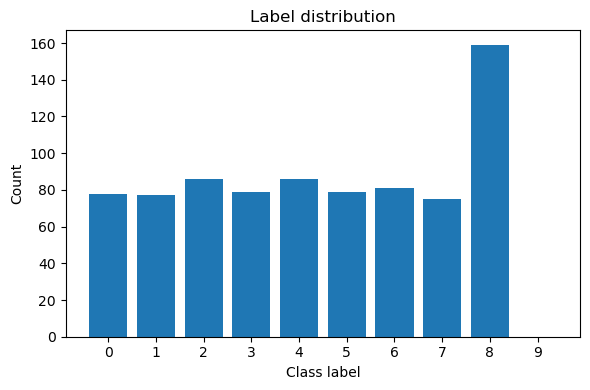

Task 1.4 passed!


In [14]:
if is_notebook():
    counts = plot_label_distribution(y_train, num_classes=10)
    assert isinstance(counts, torch.Tensor), "Expected a tensor of counts"
    assert tuple(counts.shape) == (10,), f"Expected shape (10,), got {tuple(counts.shape)}"
    assert counts.sum().item() == len(y_train)
    print("Task 1.4 passed!")

---
## Task 2: Numerical Stability and Softmax

A formula can be mathematically correct and still be numerically unstable on a computer. In this section you will implement a **naive softmax** and a **stable softmax**.

The naive softmax computes

$$
\mathrm{softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}
$$

directly. This can overflow when logits are very large. The stable softmax subtracts the maximum logit first:

$$
\mathrm{softmax}(z_i)=\frac{e^{z_i-\max(z)}}{\sum_j e^{z_j-\max(z)}}
$$

This gives the same probabilities mathematically, but avoids overflow because the largest shifted logit becomes `0`.

### 2.1 Naive Softmax

Implement `naive_softmax()`. This version should use the direct definition with `torch.exp(logits)`. It will behave correctly on small logits, but may overflow on very large logits.

In [15]:
def naive_softmax(logits):
    """Naive softmax implementation.

    Args:
        logits: tensor of shape (..., C)

    Returns:
        probs: tensor of the same shape as logits
    """
    exp_logits = torch.exp(logits)
    probs = exp_logits / exp_logits.sum(dim=-1, keepdim=True)
    return probs

### 2.2 Stable Softmax

Implement `stable_softmax()`. This version should subtract the maximum logit along the class dimension before exponentiating. It should match the naive version on normal inputs, but remain finite on very large logits.

In [16]:
def stable_softmax(logits):
    """Numerically stable softmax implementation.

    Args:
        logits: tensor of shape (..., C)

    Returns:
        probs: tensor of the same shape as logits
    """
    shifted = logits - logits.max(dim=-1, keepdim=True).values
    exp_logits = torch.exp(shifted)
    probs = exp_logits / exp_logits.sum(dim=-1, keepdim=True)
    return probs

### 2.3 Comparing Naive and Stable Softmax

Implement `compare_naive_and_stable_softmax()`. This function should run both versions on the same logits and report whether the outputs are finite and whether they sum to 1. Use this to demonstrate the difference between mathematical correctness and numerical stability.

In [17]:
def compare_naive_and_stable_softmax(logits):
    """Compare naive and stable softmax on the same logits.

    Args:
        logits (torch.Tensor): tensor of shape (..., C)

    Returns:
        result (dict): must contain exactly these keys:
            "naive_probs"      (torch.Tensor) -- output of naive_softmax(logits)
            "stable_probs"     (torch.Tensor) -- output of stable_softmax(logits)
            "naive_is_finite"  (bool)         -- True if all values in naive_probs are finite
            "stable_is_finite" (bool)         -- True if all values in stable_probs are finite
    """
    naive_probs = naive_softmax(logits)
    stable_probs = stable_softmax(logits)
    result = {
        "naive_probs": naive_probs,
        "stable_probs": stable_probs,
        "naive_is_finite": bool(torch.isfinite(naive_probs).all().item()),
        "stable_is_finite": bool(torch.isfinite(stable_probs).all().item()),
    }
    return result


In [18]:
if is_notebook():
    normal_logits = torch.tensor([[1.0, 2.0, 3.0]])
    big_logits = torch.tensor([[1000.0, 1001.0, 999.0]])

    result_normal = compare_naive_and_stable_softmax(normal_logits)
    result_big = compare_naive_and_stable_softmax(big_logits)

    assert isinstance(result_normal, dict) and isinstance(result_big, dict)
    assert result_normal["stable_probs"].shape == normal_logits.shape
    assert torch.allclose(result_normal["stable_probs"].sum(dim=-1), torch.ones(1), atol=1e-5)
    assert torch.allclose(result_big["stable_probs"].sum(dim=-1), torch.ones(1), atol=1e-5)
    print("Task 2 passed!")

Task 2 passed!


### 2.4 Finite-Value Checks

Implement `check_finite_tensor()`. This helper should raise an error when a tensor contains `NaN` or `Inf`. You will use it later on logits, losses, and gradients.

In [19]:
def check_finite_tensor(tensor, name):
    """Raise an informative error if the tensor contains NaN or Inf.

    Args:
        tensor (torch.Tensor): any torch tensor
        name (str): descriptive name used in the error message

    Returns:
        None — this function has no return value

    Raises:
        Exception: raise any exception (e.g. ValueError) if tensor contains
            NaN, +Inf, or -Inf. The error message should include `name` so the
            caller knows which tensor failed.
    """
    if not torch.isfinite(tensor).all():
        raise ValueError(f"Tensor '{name}' contains NaN or Inf")


In [20]:
if is_notebook():
    good = torch.tensor([1.0, 2.0, 3.0])
    bad = torch.tensor([1.0, float("inf")])
    check_finite_tensor(good, "good")
    try:
        check_finite_tensor(bad, "bad")
        raise AssertionError("Expected check_finite_tensor to fail on Inf")
    except Exception:
        pass
    print("Task 2.4 passed!")

Task 2.4 passed!


---
## Task 3: Forward Pass and Loss Debugging

Before blaming the optimizer, inspect the model outputs and check whether they are compatible with the loss function.

In [21]:
class TinyMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

### 3.1 Inspecting Logits

Implement `inspect_logits()`. This function should report the logits shape, value range, mean, standard deviation, and whether all values are finite. It gives a quick numerical summary of the model output before the loss is applied.

In [22]:
def inspect_logits(logits):
    """Summarise a logits tensor.

    Args:
        logits (torch.Tensor): tensor of shape (batch, num_classes)

    Returns:
        info (dict): must contain exactly these keys:
            "shape"  (tuple) -- tuple(logits.shape)
            "min"    (float) -- logits.min().item()
            "max"    (float) -- logits.max().item()
            "mean"   (float) -- logits.mean().item()
            "std"    (float) -- logits.std().item()
            "finite" (bool)  -- True if all values are finite (no NaN or Inf)
    """
    info = {
        "shape": tuple(logits.shape),
        "min": float(logits.min().item()),
        "max": float(logits.max().item()),
        "mean": float(logits.mean().item()),
        "std": float(logits.std().item()),
        "finite": bool(torch.isfinite(logits).all().item()),
    }
    return info


### 3.2 Checking Loss Inputs

Implement `check_loss_inputs()`. This function should verify that logits and targets are shaped correctly for classification and that the target dtype matches the loss function. In particular, `nn.CrossEntropyLoss` expects raw logits and integer class indices.

In [23]:
def check_loss_inputs(logits, y, num_classes):
    """Validate inputs to a multiclass classification loss.

    nn.CrossEntropyLoss expects:
        - logits: float tensor of shape (batch, num_classes) — raw scores, NOT probabilities
        - y:      long tensor of shape (batch,) — integer class indices in [0, num_classes-1]

    Args:
        logits (torch.Tensor): tensor of shape (batch, num_classes)
        y (torch.Tensor): target tensor of shape (batch,)
        num_classes (int): total number of classes

    Returns:
        ok (bool): True if inputs are compatible with nn.CrossEntropyLoss

    Raises:
        Exception: raise any exception (e.g. ValueError) if:
            - y.dtype is not torch.long
            - logits.shape[0] != y.shape[0] (batch size mismatch)
            - logits.shape[1] != num_classes
    """
    if y.dtype != torch.long:
        raise ValueError(f"Targets must have dtype torch.long, got {y.dtype}")
    if logits.ndim != 2:
        raise ValueError(f"Logits must have shape (batch, num_classes), got {tuple(logits.shape)}")
    if y.ndim != 1:
        raise ValueError(f"Targets must have shape (batch,), got {tuple(y.shape)}")
    if logits.shape[0] != y.shape[0]:
        raise ValueError("Batch size mismatch between logits and targets")
    if logits.shape[1] != num_classes:
        raise ValueError(f"Expected {num_classes} classes, got {logits.shape[1]}")
    return True


In [24]:
if is_notebook():
    model = TinyMLP()
    xb, yb = next(iter(train_loader))
    logits = model(xb)

    info = inspect_logits(logits)
    assert isinstance(info, dict), "inspect_logits should return a dictionary"
    assert check_loss_inputs(logits, yb, num_classes=10) is True
    print("Task 3 passed!")

Task 3 passed!


---
## Task 4: Gradient and Training-Loop Debugging

Many deep learning bugs do **not** crash. Instead, the code runs, but the model never learns. In this section you will verify that gradients exist, parameters update, and the model can overfit a single mini-batch.

### 4.1 Gradient Summary

Implement `gradient_summary()`. This function should iterate over model parameters and report whether each gradient is `None` and, if it exists, its norm. This helps distinguish “no gradient” from “tiny gradient”.

In [25]:
def gradient_summary(model):
    """Report gradient status for each named parameter.

    Args:
        model (nn.Module): a PyTorch model

    Returns:
        summary (dict): maps each parameter name (str) to a sub-dict with:
            "grad_exists" (bool)        -- True if param.grad is not None
            "grad_norm"   (float|None)  -- param.grad.norm().item() if grad exists, else None

        Example for a model with parameters "net.0.weight" and "net.0.bias":
            {
                "net.0.weight": {"grad_exists": True,  "grad_norm": 0.342},
                "net.0.bias":   {"grad_exists": False, "grad_norm": None},
            }
    """
    summary = {}
    for name, param in model.named_parameters():
        grad_exists = param.grad is not None
        summary[name] = {
            "grad_exists": grad_exists,
            "grad_norm": float(param.grad.norm().item()) if grad_exists else None,
        }
    return summary


### 4.2 Parameter Update Norm

Implement `parameter_update_norm()`. This function should compare model parameters before and after `optimizer.step()` and measure how much they changed. It is a direct check that optimization is actually updating the weights.

In [26]:
def parameter_update_norm(model, old_params):
    """Measure how much each parameter changed after an optimizer step.

    Args:
        model (nn.Module): model whose parameters have just been updated
        old_params (dict): maps parameter name (str) to a tensor snapshot taken
            BEFORE the optimizer step (e.g. via {n: p.detach().clone() ...})

    Returns:
        update_info (dict): maps each parameter name (str) to a sub-dict with:
            "update_norm" (float) -- (current_param - old_param).norm().item()

        Example:
            {
                "net.0.weight": {"update_norm": 0.021},
                "net.0.bias":   {"update_norm": 0.005},
            }
    """
    update_info = {}
    for name, param in model.named_parameters():
        update_info[name] = {
            "update_norm": float((param.detach() - old_params[name]).norm().item())
        }
    return update_info


### 4.4 Overfitting a Single Batch

Implement `overfit_single_batch()`. This function should train the model on **one** mini-batch for several steps and record the loss history. This is one of the most useful debugging tests in practice: if the model cannot memorize a single batch, something fundamental is broken.

In [27]:
def overfit_single_batch(model, batch, loss_fn, optimizer, steps):
    """Train on one batch repeatedly and record the loss.

    Args:
        model: nn.Module
        batch: tuple (x, y)
        loss_fn: classification loss
        optimizer: torch optimizer
        steps: number of repeated updates

    Returns:
        losses (list[float]): loss value after each update
    """
    x, y = batch
    device = next(model.parameters()).device
    x = x.to(device)
    y = y.to(device)
    model.train()
    losses = []

    for _ in range(steps):
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.item()))

    return losses

### 4.5 Train vs Eval Mode                                                                                                                         
                  
  Implement `check_model_mode()`. This function should report whether the model is in training mode or evaluation mode, and list any submodules whose
   behaviour differs between the two modes.

  The following PyTorch module types change behaviour between `train()` and `eval()` mode:                                                           
                                          
  - `nn.Dropout`, `nn.Dropout1d`, `nn.Dropout2d`, `nn.Dropout3d` — randomly zeroes elements during training; passes input through unchanged during   
  evaluation.                                                                                                                                        
  - `nn.BatchNorm1d`, `nn.BatchNorm2d`, `nn.BatchNorm3d` — uses current-batch statistics during training; uses stored running statistics during
  evaluation.                                                                                                                                        
  - `nn.LayerNorm` — behaves the same in both modes but is conventionally listed as mode-sensitive.
                                                                                                                                                     
  **Hint:** Use `model.named_modules()` to iterate over all submodules. It yields `(name, module)` pairs — check `isinstance(module, ...)` against   
  the types above to build the list of affected names.

In [28]:
def check_model_mode(model):
      """Report the model's current training/eval mode.

      Args:
          model (nn.Module): a PyTorch model
                                              
      Returns:                            
          info (dict): must contain exactly these keys:
              "training"           (bool)      -- True if model.training is True, False otherwise                                                    
              "affected_submodules" (list[str]) -- names of submodules whose behaviour differs
                  between train and eval mode: nn.Dropout (and variants), nn.BatchNorm1d/2d/3d,                                                      
                  and nn.LayerNorm. Use an empty list [] if none exist.
      """                                 
      AFFECTED_TYPES = (                                                                                                                             
          nn.Dropout, nn.Dropout1d, nn.Dropout2d, nn.Dropout3d,                                                                                      
          nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d,                                                                                            
          nn.LayerNorm,                                                                                                                              
      )                                                                                                                                              
      affected_submodules = [name for name, module in model.named_modules() if name and isinstance(module, AFFECTED_TYPES)]
      info = {
          "training": model.training,
          "affected_submodules": affected_submodules,
      }
      return info

In [29]:
if is_notebook():
    model = TinyMLP()
    xb, yb = next(iter(train_loader))
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    losses = overfit_single_batch(
        TinyMLP(),
        next(iter(train_loader)),
        nn.CrossEntropyLoss(),
        torch.optim.SGD(TinyMLP().parameters(), lr=0.1),
        steps=5
    )
    assert isinstance(losses, list), "overfit_single_batch should return a list"
    mode_info = check_model_mode(model)
    assert isinstance(mode_info, dict), "check_model_mode should return a dictionary"
    print("Task 4 passed!")

Task 4 passed!


---
## Task 5: Autograd Pitfalls and In-Place Operations

PyTorch tracks computation graphs automatically, but some in-place tensor operations can break gradient computation. In this section you will build a tiny example that fails, then rewrite it safely.

### 5.1 In-Place Operation That Breaks Autograd

PyTorch builds a computation graph as you create tensors. When you call `.backward()`, it walks that graph to compute gradients. **In-place operations** modify a tensor's data directly instead of creating a new tensor. This can silently destroy the information PyTorch stored for the backward pass.

A subtle example: `x += 1` looks like ordinary Python arithmetic, but on a tensor it is an in-place operation (equivalent to `x.add_(1)`). The following snippet triggers an autograd error:

```python
x = torch.tensor([2.0], requires_grad=True)
y = x * 3        # y is computed from x — PyTorch saves x for the backward pass
x += 1           # in-place modification of x after the graph was built
loss = y.sum()
loss.backward()  # RuntimeError: autograd cannot differentiate through the modified x
```

Implement `run_inplace_autograd()`. The buggy code above is already inside the function body. Wrap the `loss.backward()` call in a `try/except` block, capture the error message, and return it as a string.

In [30]:
def run_inplace_autograd():
    """Demonstrate the RuntimeError caused by an in-place operation breaking autograd.

    The function body already contains the broken code. Your job is to wrap
    the backward call (loss.backward()) in a try/except block, capture the
    RuntimeError message, and return it as a string.

    Returns:
        msg (str): the RuntimeError message string raised by loss.backward(),
            or "no error" if backward succeeded unexpectedly.
    """
    try:
        x = torch.tensor([2.0], requires_grad=True)
        y = x * 3
        x += 1           # in-place modification
        loss = y.sum()
        loss.backward()
    except RuntimeError as e:
        return str(e)
    return "no error"


### 5.2 Fixing the In-Place Operation

Implement `fix_inplace_autograd_issue()`. This function should rewrite the same computation using an out-of-place operation so that `backward()` succeeds and gradients can be computed safely.

In [31]:
def fix_inplace_autograd_issue():
    """Rewrite the broken example using safe out-of-place operations.

    Returns:
        grad (torch.Tensor): a gradient tensor proving backward() succeeded
    """
    x = torch.tensor([2.0], requires_grad=True)
    x_safe = x + 1
    y = x_safe * 3
    loss = y.sum()
    loss.backward()
    grad = x.grad
    return grad

In [32]:
if is_notebook():
    run_inplace_autograd()
    grad = fix_inplace_autograd_issue()
    assert isinstance(grad, torch.Tensor), "Expected a tensor gradient"
    assert torch.isfinite(grad).all(), "Gradient should be finite"
    print("Task 5 passed!")

Task 5 passed!


---
## Task 6: Final Integrated Bug Hunt

You are now given a deliberately broken classification pipeline. Use the helper functions you implemented above to debug it **systematically** rather than guessing.

The broken pipeline contains several realistic bugs — not all of them crash. Some are silent failures where the code runs but the model never learns:

- a label encoding bug hidden in the dataset's `__getitem__` (you should have already spotted this in Task 1)
- a model architecture choice that is incompatible with the loss function
- three training-loop bugs

Implement the fixed versions below, then the training cell will run **two experiments side by side**:

1. **Buggy labels, correct val** — trains with `StringLabelDataset` (buggy, `"j"` → `8`) but evaluates using your `FixedStringLabelDataset` (correct, `"j"` → `9`). The training loss will converge, but validation accuracy will plateau well below 100% because the model never sees class 9 and will always misclassify `"j"` examples at evaluation time.
2. **Fixed labels, correct val** — trains and evaluates using `FixedStringLabelDataset`. With all bugs fixed the model should reach at least 75% validation accuracy.

In [33]:
class BrokenMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, num_classes),
            nn.Softmax(dim=1),
        )

    def forward(self, x):
        return self.net(x)


def broken_train_epoch(model, loader, optimizer, loss_fn):
    """A deliberately broken training epoch."""
    model.eval()
    running_loss = 0.0

    for xb, yb in loader:
        yb = yb.float()
        optimizer.zero_grad()

        logits = model(xb)

        loss = loss_fn(logits, yb)
        loss.backward()

        running_loss += loss.item()

    return running_loss / len(loader)

In [34]:
class FixedStringLabelDataset(Dataset):
    """Dataset with a correct string-to-integer label mapping."""

    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = torch.tensor([float(row['x1']), float(row['x2'])], dtype=torch.float32)
        label_map = {c: i for i, c in enumerate('abcdefghij')}
        y = label_map[row['class_label']]
        return x, torch.tensor(y, dtype=torch.long)


class FixedMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def fixed_train_epoch(model, loader, optimizer, loss_fn):
    """Run one full training epoch over the dataloader.

    For each batch:
      - set the model to training mode
      - zero the gradients
      - forward pass to get logits
      - compute the loss
      - backward pass
      - optimizer step

    Args:
        model: nn.Module
        loader: DataLoader yielding (x, y) batches
        optimizer: torch optimizer
        loss_fn: classification loss (e.g. nn.CrossEntropyLoss)

    Returns:
        avg_loss (float): mean loss over all batches in the epoch
    """
    model.train()
    running_loss = 0.0
    device = next(model.parameters()).device

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    return running_loss / len(loader)


def fixed_eval_accuracy(model, loader):
    """Evaluate classification accuracy on a dataloader without updating weights.

    For each batch:
      - set the model to evaluation mode
      - disable gradient computation
      - forward pass to get logits
      - take the argmax over the class dimension as the predicted label
      - compare predictions to ground-truth targets

    Args:
        model: nn.Module
        loader: DataLoader yielding (x, y) batches

    Returns:
        accuracy (float): fraction of correctly classified examples across the full loader
    """
    model.eval()
    device = next(model.parameters()).device
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += int((preds == yb).sum().item())
            total += yb.shape[0]

    return correct / total


[Buggy labels] Epoch 00: train_loss=1.4923, val_acc=0.7150
[Buggy labels] Epoch 01: train_loss=0.8553, val_acc=0.8600
[Buggy labels] Epoch 02: train_loss=0.6562, val_acc=0.8700
[Buggy labels] Epoch 03: train_loss=0.5487, val_acc=0.8750
[Buggy labels] Epoch 04: train_loss=0.4803, val_acc=0.8800
[Buggy labels] Epoch 05: train_loss=0.4296, val_acc=0.8700
[Buggy labels] Epoch 06: train_loss=0.3903, val_acc=0.8800
[Buggy labels] Epoch 07: train_loss=0.3611, val_acc=0.8850
[Buggy labels] Epoch 08: train_loss=0.3391, val_acc=0.8850
[Buggy labels] Epoch 09: train_loss=0.3234, val_acc=0.8900
[Fixed labels]  Epoch 00: train_loss=1.6018, val_acc=0.6750
[Fixed labels]  Epoch 01: train_loss=0.9695, val_acc=0.9200
[Fixed labels]  Epoch 02: train_loss=0.7531, val_acc=0.8650
[Fixed labels]  Epoch 03: train_loss=0.6352, val_acc=0.9450
[Fixed labels]  Epoch 04: train_loss=0.5595, val_acc=0.9550
[Fixed labels]  Epoch 05: train_loss=0.4996, val_acc=0.9600
[Fixed labels]  Epoch 06: train_loss=0.4569, val_a

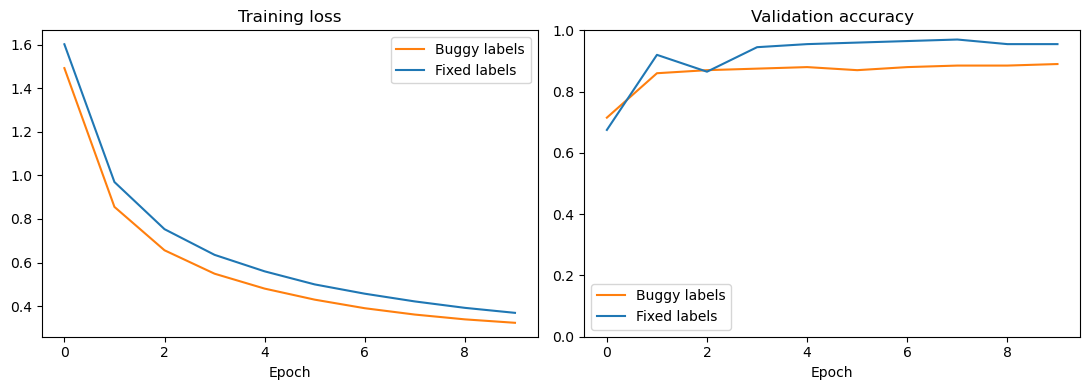

In [35]:
if is_notebook():
    # --- Experiment 1: buggy labels for training, correct labels for validation ---
    buggy_train_loader = DataLoader(StringLabelDataset(train_df),      batch_size=64,  shuffle=True)
    correct_val_loader = DataLoader(FixedStringLabelDataset(val_df),   batch_size=128, shuffle=False)

    buggy_model = FixedMLP()  # architecture is fixed; only the label bug is active
    buggy_opt   = torch.optim.SGD(buggy_model.parameters(), lr=0.1)
    loss_fn     = nn.CrossEntropyLoss()

    buggy_train_losses, buggy_val_accs = [], []
    for epoch in range(10):
        tl = fixed_train_epoch(buggy_model, buggy_train_loader, buggy_opt, loss_fn)
        va = fixed_eval_accuracy(buggy_model, correct_val_loader)
        buggy_train_losses.append(tl)
        buggy_val_accs.append(va)
        print(f'[Buggy labels] Epoch {epoch:02d}: train_loss={tl:.4f}, val_acc={va:.4f}')

    # --- Experiment 2: fixed labels for both training and validation ---
    fixed_train_loader = DataLoader(FixedStringLabelDataset(train_df), batch_size=64,  shuffle=True)
    fixed_val_loader   = DataLoader(FixedStringLabelDataset(val_df),   batch_size=128, shuffle=False)

    fixed_model = FixedMLP()
    fixed_opt   = torch.optim.SGD(fixed_model.parameters(), lr=0.1)

    fixed_train_losses, fixed_val_accs = [], []
    for epoch in range(10):
        tl = fixed_train_epoch(fixed_model, fixed_train_loader, fixed_opt, loss_fn)
        va = fixed_eval_accuracy(fixed_model, fixed_val_loader)
        fixed_train_losses.append(tl)
        fixed_val_accs.append(va)
        print(f'[Fixed labels]  Epoch {epoch:02d}: train_loss={tl:.4f}, val_acc={va:.4f}')

    # --- Side-by-side comparison ---
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(buggy_train_losses, label='Buggy labels', color='tab:orange')
    axes[0].plot(fixed_train_losses, label='Fixed labels',  color='tab:blue')
    axes[0].set_title('Training loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(buggy_val_accs, label='Buggy labels', color='tab:orange')
    axes[1].plot(fixed_val_accs, label='Fixed labels',  color='tab:blue')
    axes[1].set_title('Validation accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0.0, 1.0)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 6.1 Confusion Matrix

Implement `compute_accuracy()` and `debug_confusion_matrix()`. Use them to verify that your fixed pipeline predicts all 10 classes correctly.

Then plot two confusion matrices side by side:
1. Predictions from a model trained on **buggy labels** (using `StringLabelDataset`).
2. Predictions from a model trained on **correct labels** (using `FixedStringLabelDataset`).

Use these plots to answer Written Question Q4: how does the label encoding bug manifest in the confusion matrix?

In [36]:
def compute_accuracy(logits, y):
    """Compute multiclass accuracy from raw logits.

    Args:
        logits: tensor of shape (batch, num_classes)
        y: tensor of shape (batch,)

    Returns:
        acc (float): fraction of correct predictions
    """
    preds = logits.argmax(dim=1)
    acc = float((preds == y).float().mean().item())
    return acc


def debug_confusion_matrix(logits, y, num_classes):
    """Build a confusion matrix from predictions and labels.

    Args:
        logits: tensor of shape (batch, num_classes)
        y: tensor of shape (batch,)
        num_classes: total number of classes

    Returns:
        cm: long tensor of shape (num_classes, num_classes)
    """
    preds = logits.argmax(dim=1)
    cm = torch.zeros((num_classes, num_classes), dtype=torch.long)
    for true_label, pred_label in zip(y, preds):
        cm[int(true_label.item()), int(pred_label.item())] += 1
    return cm

In [37]:
if is_notebook():
    logits = torch.tensor([[1.0, 0.0, -1.0], [0.1, 3.0, 0.2]])
    y = torch.tensor([0, 1])
    acc = compute_accuracy(logits, y)
    cm = debug_confusion_matrix(logits, y, num_classes=3)

    assert isinstance(acc, float), "Accuracy should be a float"
    assert isinstance(cm, torch.Tensor), "Confusion matrix should be a tensor"
    assert tuple(cm.shape) == (3, 3)
    print("Task 6.1 passed!")

Task 6.1 passed!


### Written Question Q4

The label encoding bug maps class `"j"` to label `8` instead of `9` during training. As a result, the model does not learn a separate class `9`.

In the confusion matrix for the buggy-label model, many true class-`9` examples are predicted as class `8`, so class `9` has weak or missing diagonal entries. This makes classes `8` and `9` appear collapsed into one category.

In the correctly labelled model, class `9` appears on the diagonal like the other classes, showing that the model has learned all 10 classes separately.
